In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

In [16]:
import os
import pandas as pd
import numpy as np
ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'chembl_augmented_valid.csv'),usecols=['SMILES'])
df.columns = ['smiles']
df

,smiles
0,CCO
1,OCC
2,C
3,CO
4,OC
...,...
6267871,O(C1C(O)C(n2c(=O)nc(N)cc2)OC1COP(O)(OC1C(O)C(n...
6267872,CC1=CN(C2CC(OP(O)(=O)OCC3OC(C(O)C3OP(O)(=O)OCC...
6267873,C1(O)C(OP(O)(=O)OCC2C(OP(=O)(O)OCC3OC(n4c5[nH]...
6267874,n1(C2CC(OP(O)(=O)OCC3OC(n4c(=O)nc(N)cc4)C(O)C3...


In [17]:
from rdkit_utils import *

df_med = df[df.smiles.str.len() > 10]
df_med = df_med[df.smiles.str.len() < 20]
df_med['smiles'] = df_med.smiles.apply(lambda x: get_cansmiles(x))
df_med.drop_duplicates(inplace=True)
df_med

,smiles
281,NCCCC(=O)O
288,Nc1ccccc1
355,ClCCNCCCl
456,N#CN1CCC1
459,Cc1ccccc1
...,...
138496,Cc1cc(=O)c(O)c(CCl)o1
138575,CCCc1occc(=O)c1CC=O
2876658,Nc1ncnc2ccsc12
3234798,Clc1ncnc2ccsc12


In [25]:
df_samp = df_med.sample(50, replace=False)
df_samp.head(5)

,smiles
13865,N#CC(C#N)C=NCCO
18070,O=NN1CCCCCCCCCC1
55811,NCC(=O)NCP(=O)(O)CO
15833,Oc1cccc2ncccc12
1612,N#CCCSC#N


In [26]:
def tokenize(smiles, tokens=None):
    if tokens is None:
        tokens = list(set(''.join(smiles)))
        tokens = list(np.sort(tokens))
        tokens = ''.join(tokens)
    return tokens
tok = tokenize('COC(=O)C(Br)C(C)F')
tok

'()=BCFOr'

In [27]:
from collections import Counter
# vocab = [x for x in ''.join(df_med.smiles) if x in 'cCN'
Counter(vocab)

Counter({'N': 13227,
         'C': 62429,
         '(': 16291,
         '=': 10980,
         'O': 16972,
         ')': 16291,
         'c': 45021,
         '1': 22870,
         'l': 1342,
         '#': 820,
         '[': 1568,
         '-': 443,
         ']': 1568,
         '+': 363,
         'S': 2787,
         'n': 7120,
         'F': 794,
         'B': 580,
         'r': 580,
         's': 974,
         'P': 334,
         'H': 1013,
         'I': 239,
         'o': 505,
         '2': 6109,
         '3': 132,
         '4': 4,
         '5': 2})

In [23]:
symb_to_count = {
    'C':61087,
    'c':45021,
    'N':13227,
    'n':7120,
    'O':16972,
    'o':505,
    'F':794,
    'P':334,
    'S':2787,
    's':974,
    'Cl':1342,
    'Br':580,
    'I':239
}

,smiles,mol
281,NCCCC(=O)O,
288,Nc1ccccc1,
355,ClCCNCCCl,
456,N#CN1CCC1,
459,Cc1ccccc1,
462,NCc1ccccc1,
497,NCCNCCNCCN,
500,OCc1ccccc1,
534,CN1CCNCC1,
735,[N-]=[N+]=N,

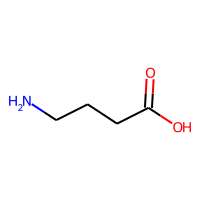
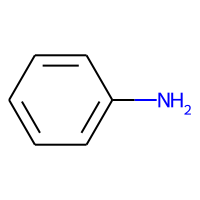
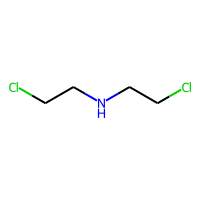
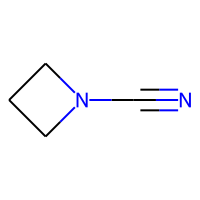
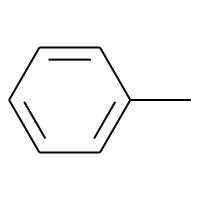
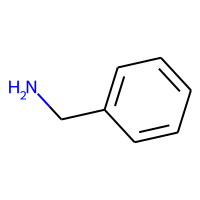
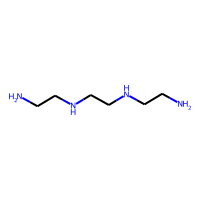
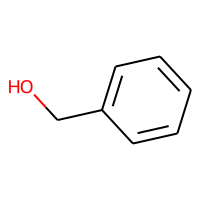
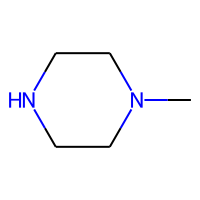
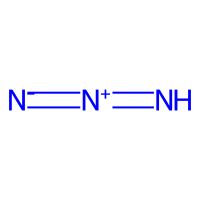

In [5]:
from rdkit.Chem import PandasTools

def displaydf(df):
    return HTML(df.to_html(notebook=True))

PandasTools.AddMoleculeColumnToFrame(df_med,'smiles','mol',includeFingerprints=False)
displaydf(df_med[:10])